# I want to repurpose the existing code for visualizing our models' performances

In [1]:
MODEL_NAME = 'greedy_search_dec2enc3_len100'
k = 5  # how many lowest/highest values to show

In [2]:
# wait isn't this really hard to do?
# actually I could import the trainer class like in train_model.py, and see from there...
from omegaconf import OmegaConf
from cnn_transformer_trainer import BrainToText_Trainer

args = OmegaConf.load(f'metrics/{MODEL_NAME}/args.yaml')

In [3]:
# safety check
args['dataset_dir'] = '../../data/hdf5_data_final'

args['mode'] = 'x'
args['save_best_checkpoint'] = False
args['init_from_checkpoint'] = True
args['output_dir'] = f'trained_models/{MODEL_NAME}'
args['checkpoint_dir'] = f'trained_models/{MODEL_NAME}/checkpoint'
args['init_checkpoint_path'] = f'trained_models/{MODEL_NAME}/checkpoint/best_checkpoint'


print(args['mode'])
print(args['save_best_checkpoint'])
print(args['init_from_checkpoint'])
print(args['output_dir']) # should be trained_models/<model>
print(args['checkpoint_dir']) # should be trained_models/<model>/checkpoint
print(args['init_checkpoint_path']) # should be trained_models/<model>/checkpoint/best_checkpoint
                                    # if the next cell doesn't work, it's because best_checkpoint is still best_checkpoint.zip
                                    # rename best_checkpoint.zip to best_checkpoint in that case.

x
False
True
trained_models/greedy_search_dec2enc3_len100
trained_models/greedy_search_dec2enc3_len100/checkpoint
trained_models/greedy_search_dec2enc3_len100/checkpoint/best_checkpoint


# Creating Dummy class to debug something

In [4]:
import torch
from torch.utils.data import DataLoader
import os
import logging
from dataset import BrainToTextDataset, train_test_split_indicies
from data_augmentations import gauss_smooth

import torchaudio.functional as F # for edit distance

from cnn_transformer_model import CNNTransformer # our transformer model with beam search

class Dummy:
    def __init__(self, args):
        self.args = args

        self.transform_args = self.args['dataset']['data_transforms']

        # Set up logging
        self.logger = logging.getLogger(__name__)
        for handler in self.logger.handlers[:]:  # make a copy of the list
            self.logger.removeHandler(handler)
        self.logger.setLevel(logging.INFO)
        formatter = logging.Formatter(fmt='%(asctime)s: %(message)s')

        # Configure device pytorch will use
        if torch.cuda.is_available():
            gpu_num = self.args.get('gpu_number', 0)
            try:
                gpu_num = int(gpu_num)
            except ValueError:
                self.logger.warning(f"Invalid gpu_number value: {gpu_num}. Using 0 instead.")
                gpu_num = 0

            max_gpu_index = torch.cuda.device_count() - 1
            if gpu_num > max_gpu_index:
                self.logger.warning(f"Requested GPU {gpu_num} not available. Using GPU 0 instead.")
                gpu_num = 0

            try:
                self.device = torch.device(f"cuda:{gpu_num}")
                test_tensor = torch.tensor([1.0]).to(self.device)
                test_tensor = test_tensor * 2
            except Exception as e:
                self.logger.error(f"Error initializing CUDA device {gpu_num}: {str(e)}")
                self.logger.info("Falling back to CPU")
                self.device = torch.device("cpu")
        else:
            self.device = torch.device("cpu")

        self.logger.info(f'Using device: {self.device}')

        self.model = CNNTransformer(
            neural_dim=self.args['model']['n_input_features'],
            n_units=self.args['model']['n_units'],
            n_days=len(self.args['dataset']['sessions']),
            n_classes=self.args['dataset']['n_classes'],

            # conv config
            conv_channels=self.args['model']['conv_channels'],
            conv_kernel_sizes=self.args['model']['conv_kernel_sizes'],
            conv_strides=self.args['model']['conv_strides'],
            conv_residual=self.args['model']['conv_residual'],

            # transformer config
            enc_layers=self.args['model']['enc_layers'],
            dec_layers=self.args['model']['dec_layers'],
            n_heads=self.args['model']['n_heads'],
            dim_feedforward=self.args['model']['dim_feedforward'],
            trans_dropout=self.args['model']['trans_dropout'],
            input_dropout=self.args['model']['input_network']['input_layer_dropout'],
            activation=self.args['model']['activation'],
            max_len=self.args['model']['max_len'],
        )

        # Create datasets and dataloaders
        train_file_paths = [os.path.join(self.args["dataset"]["dataset_dir"], s, 'data_train.hdf5') for s in
                            self.args['dataset']['sessions']]
        val_file_paths = [os.path.join(self.args["dataset"]["dataset_dir"], s, 'data_val.hdf5') for s in
                          self.args['dataset']['sessions']]

        # Split trials into train and test sets
        train_trials, _ = train_test_split_indicies(
            file_paths=train_file_paths,
            test_percentage=0,
            seed=self.args['dataset']['seed'],
            bad_trials_dict=None,
        )
        _, val_trials = train_test_split_indicies(
            file_paths=val_file_paths,
            test_percentage=1,
            seed=self.args['dataset']['seed'],
            bad_trials_dict=None,
        )

        # Determine if a only a subset of neural features should be used
        feature_subset = None
        if ('feature_subset' in self.args['dataset']) and self.args['dataset']['feature_subset'] != None:
            feature_subset = self.args['dataset']['feature_subset']
            self.logger.info(f'Using only a subset of features: {feature_subset}')

        # train dataset and dataloader
        self.train_dataset = BrainToTextDataset(
            trial_indicies=train_trials,
            split='train',
            days_per_batch=self.args['dataset']['days_per_batch'],
            n_batches=self.args['num_training_batches'],
            batch_size=self.args['dataset']['batch_size'],
            must_include_days=None,
            random_seed=self.args['dataset']['seed'],
            feature_subset=feature_subset
        )
        self.train_loader = DataLoader(
            self.train_dataset,
            batch_size=None,  # Dataset.__getitem__() already returns batches
            shuffle=self.args['dataset']['loader_shuffle'],
            num_workers=self.args['dataset']['num_dataloader_workers'],
            pin_memory=True
        )

        # val dataset and dataloader
        self.val_dataset = BrainToTextDataset(
            trial_indicies=val_trials,
            split='test',
            days_per_batch=None,
            n_batches=None,
            batch_size=self.args['dataset']['batch_size'],
            must_include_days=None,
            random_seed=self.args['dataset']['seed'],
            feature_subset=feature_subset
        )
        self.val_loader = DataLoader(
            self.val_dataset,
            batch_size=None,  # Dataset.__getitem__() already returns batches
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )

    def transform_data(self, features, n_time_steps, mode='train'):
        '''
        Apply various augmentations and smoothing to data
        Performing augmentations is much faster on GPU than CPU
        '''

        data_shape = features.shape
        batch_size = data_shape[0]
        channels = data_shape[-1]

        # We only apply these augmentations in training
        if mode == 'train':
            # add static gain noise
            if self.transform_args['static_gain_std'] > 0:
                warp_mat = torch.tile(torch.unsqueeze(torch.eye(channels), dim=0), (batch_size, 1, 1))
                warp_mat += torch.randn_like(warp_mat, device=self.device) * self.transform_args['static_gain_std']

                features = torch.matmul(features, warp_mat)

            # add white noise
            if self.transform_args['white_noise_std'] > 0:
                features += torch.randn(data_shape, device=self.device) * self.transform_args['white_noise_std']

            # add constant offset noise
            if self.transform_args['constant_offset_std'] > 0:
                features += torch.randn((batch_size, 1, channels), device=self.device) * self.transform_args[
                    'constant_offset_std']

            # add random walk noise
            if self.transform_args['random_walk_std'] > 0:
                features += torch.cumsum(
                    torch.randn(data_shape, device=self.device) * self.transform_args['random_walk_std'],
                    dim=self.transform_args['random_walk_axis'])

            # randomly cutoff part of the data timecourse
            if self.transform_args['random_cut'] > 0:
                cut = np.random.randint(0, self.transform_args['random_cut'])
                features = features[:, cut:, :]
                n_time_steps = n_time_steps - cut

        # Apply Gaussian smoothing to data
        # This is done in both training and validation
        if self.transform_args['smooth_data']:
            features = gauss_smooth(
                inputs=features,
                device=self.device,
                smooth_kernel_std=self.transform_args['smooth_kernel_std'],
                smooth_kernel_size=self.transform_args['smooth_kernel_size'],
            )

        return features, n_time_steps


    def validation(self, loader, return_logits=False, return_data=False):
        '''
        Calculate metrics on the validation dataset
        '''
        self.model.eval()

        metrics = {}

        # Record metrics
        if return_logits:
            metrics['logits'] = []
            metrics['n_time_steps'] = []

        if return_data:
            metrics['input_features'] = []

        metrics['decoded_seqs'] = []
        metrics['true_seq'] = []
        metrics['phone_seq_lens'] = []
        metrics['transcription'] = []
        metrics['losses'] = []
        metrics['block_nums'] = []
        metrics['trial_nums'] = []
        metrics['day_indicies'] = []

        total_edit_distance = 0
        total_seq_length = 0

        # Calculate PER for each specific day
        day_per = {}
        for d in range(len(self.args['dataset']['sessions'])):
            if self.args['dataset']['dataset_probability_val'][d] == 1:
                day_per[d] = {'total_edit_distance': 0, 'total_seq_length': 0}

        # Constants for special tokens
        SOS_IDX = 41
        EOS_IDX = 42
        PAD_IDX = 0

        # Greedy search parameter from config
        max_decode_length = self.args.get('greedy_search', {}).get('max_decode_length', 100)

        for i, batch in enumerate(loader):

            features = batch['input_features'].to(self.device)
            labels = batch['seq_class_ids'].to(self.device)
            n_time_steps = batch['n_time_steps'].to(self.device)
            phone_seq_lens = batch['phone_seq_lens'].to(self.device)
            day_indicies = batch['day_indicies'].to(self.device)

            # Determine if we should perform validation on this batch
            day = day_indicies[0].item()
            if self.args['dataset']['dataset_probability_val'][day] == 0:
                if self.args['log_val_skip_logs']:
                    self.logger.info(f"Skipping validation on day {day}")
                continue

            batch_size = features.size(0)

            with torch.no_grad():
                with torch.autocast(device_type="cuda", enabled=self.args['use_amp'], dtype=torch.bfloat16):
                    features, n_time_steps = self.transform_data(features, n_time_steps, 'val')

                    # ====================================================
                    # PASS 1: TEACHER FORCING (To calculate LOSS)
                    # ====================================================
                    sos_col = torch.full((batch_size, 1), SOS_IDX, device=self.device, dtype=torch.long)
                    tgt_input = torch.cat([sos_col, labels], dim=1)

                    # Construct y_true with EOS for loss calculation
                    y_true = torch.zeros((batch_size, labels.size(1) + 1), dtype=torch.long, device=self.device)
                    y_true[:, :labels.size(1)] = labels
                    y_true.scatter_(1, phone_seq_lens.unsqueeze(1), EOS_IDX)

                    # Align lengths
                    tgt_input = tgt_input[:, :y_true.size(1)]

                    # Forward pass
                    tf_logits = self.model(features, day_indicies, tgt=tgt_input)

                    # Calculate CrossEntropyLoss
                    # Note: We use torch.nn.functional to prevent conflicts with the torchvision F
                    val_loss = torch.nn.functional.cross_entropy(
                        tf_logits.reshape(-1, self.model.internal_vocab_size),
                        y_true.reshape(-1),
                        ignore_index=PAD_IDX
                    )

                    # Store Loss
                    metrics['losses'].append(val_loss.item())

                    # ====================================================
                    # PASS 2: GREEDY SEARCH (To calculate PER)
                    # ====================================================

                    # A. Manual Encode (Get 'memory')
                    # --------------------------------
                    day_weights = torch.stack([self.model.day_weights[i] for i in day_indicies], dim=0)
                    day_biases = torch.cat([self.model.day_biases[i] for i in day_indicies], dim=0).unsqueeze(1)
                    x_enc = torch.einsum("btd,bdk->btk", features, day_weights) + day_biases
                    x_enc = self.model.day_layer_activation(x_enc)

                    x_enc = x_enc.permute(0, 2, 1)
                    x_enc = self.model.conv_frontend(x_enc)
                    x_enc = x_enc.permute(0, 2, 1)

                    src = self.model.input_proj(x_enc)
                    src = torch.nn.functional.gelu(src)
                    src = self.model.pos_encoding(src)
                    memory = self.model.encoder(src)

                    # ====================================================
                    # GREEDY DECODING
                    # ====================================================
                    generated = self.model.greedy_decode(memory, max_length=max_decode_length)

                    # ====================================================
                    # CALCULATE METRICS
                    # ====================================================

                    batch_edit_distance = 0
                    decoded_seqs = []

                    # generated contains: [SOS, Pred1, Pred2, EOS, PAD...]

                    for iterIdx in range(batch_size):
                        # 1. Process Predicted Sequence
                        # Get row, remove SOS (first item) immediately
                        raw_pred = generated[iterIdx][1:]

                        # Filter out EOS and everything after it, and PADs
                        valid_indices = []
                        for token in raw_pred:
                            if token == EOS_IDX: break  # Stop at EOS
                            if token == PAD_IDX: continue  # Skip Pad
                            valid_indices.append(token.item())

                        # Convert to Tensor for torchaudio.functional.edit_distance
                        decoded_seq_tensor = torch.tensor(valid_indices, device=self.device, dtype=torch.long)

                        # Store for logging (numpy for serialization)
                        decoded_seqs.append(np.array(valid_indices))

                        # 2. Process True Sequence
                        # labels has 0 as padding, and NO EOS/SOS
                        raw_true = labels[iterIdx][0: phone_seq_lens[iterIdx]]
                        # raw_true is already clean (no pads due to slicing)

                        # 3. Calc Edit Distance
                        # F here is torchaudio.functional
                        dist = F.edit_distance(decoded_seq_tensor, raw_true)
                        batch_edit_distance += dist

            # Update totals
            day = batch['day_indicies'][0].item()

            day_per[day]['total_edit_distance'] += batch_edit_distance
            day_per[day]['total_seq_length'] += torch.sum(phone_seq_lens).item()

            total_edit_distance += batch_edit_distance
            total_seq_length += torch.sum(phone_seq_lens)

            # Record metrics
            if return_logits:
                # Log the Teacher Forcing logits (loss-related)
                metrics['logits'].append(tf_logits.cpu().float().numpy())
                # Log the length of the *Generated* sequence
                gen_lens = torch.full((batch_size,), generated.size(1), device='cpu')
                metrics['n_time_steps'].append(gen_lens.numpy())

            if return_data:
                metrics['input_features'].append(batch['input_features'].cpu().numpy())

            metrics['decoded_seqs'].append(decoded_seqs)
            metrics['true_seq'].append(batch['seq_class_ids'].cpu().numpy())
            metrics['phone_seq_lens'].append(batch['phone_seq_lens'].cpu().numpy())
            metrics['transcription'].append(batch['transcriptions'].cpu().numpy())
            # metrics['losses'] appended earlier inside the loop
            metrics['block_nums'].append(batch['block_nums'].numpy())
            metrics['trial_nums'].append(batch['trial_nums'].numpy())
            metrics['day_indicies'].append(batch['day_indicies'].cpu().numpy())

        avg_PER = total_edit_distance / total_seq_length

        metrics['day_PERs'] = day_per
        metrics['avg_PER'] = avg_PER
        metrics['avg_loss'] = np.mean(metrics['losses'])

        return metrics

In [5]:
trainer = Dummy(args)
model = trainer.model.to(device=trainer.device)

# load model weights
# for whatever reason, this only works when I put it outside the Dummy class...
checkpoint = torch.load(args['init_checkpoint_path'], weights_only=False)
cleaned = {}
for key, value in checkpoint['model_state_dict'].items():
    new_key = key
    if new_key.startswith("module."):
        new_key = new_key[len("module."):]
    if new_key.startswith("_orig_mod."):
        new_key = new_key[len("_orig_mod."):]
    cleaned[new_key] = value

checkpoint['model_state_dict'] = cleaned
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [6]:
import h5py
import torch
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# File paths
TRAIN_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_train.hdf5"
TEST_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_test.hdf5"

# --- Explore Data ---
def explore_data():
    print("Exploring training data...")
    with h5py.File(TRAIN_FILE, 'r') as f:
        trials = list(f.keys())
        print(f"Number of training trials: {len(trials)}")
        
        # Analyze sequence lengths and labels
        neural_lengths = []
        for trial_key in trials[:5]:
            trial = f[trial_key]
            neural_len = trial['input_features'].shape[0]
            label_len = trial['seq_class_ids'].shape[0]
            neural_lengths.append(neural_len)
            print(f"{trial_key}: neural={neural_len}, labels={label_len}")
            
        print(f"\nNeural length stats: min={min(neural_lengths)}, max={max(neural_lengths)}, avg={np.mean(neural_lengths):.1f}")

explore_data()

Using device: cuda
Exploring training data...
Number of training trials: 59
trial_0000: neural=950, labels=500
trial_0001: neural=932, labels=500
trial_0002: neural=939, labels=500
trial_0003: neural=701, labels=500
trial_0004: neural=513, labels=500

Neural length stats: min=513, max=950, avg=807.0


In [7]:
print(trainer.train_dataset)
print(trainer.train_loader)
print(trainer.val_dataset)
print(trainer.val_loader)

In [8]:
len(trainer.train_loader)

100000

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
def analyze_loader_batches(loader, name="Dataset", n_batches=3):
    """
    Analyze the first `n_batches` from a DataLoader.

    Note:
        - Each batch contains multiple trials.
        - This function only inspects the first `n_batches`.
        - It does NOT randomly sample trials across the whole dataset.
    """
    total_trials = 0
    total_time_steps = []
    total_seq_lens = []
    day_counts = {}

    print(f"\n{name}: analyzing first {n_batches} batches (sequential)")

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= n_batches:
            break

        batch_size = batch['input_features'].shape[0]
        total_trials += batch_size

        total_time_steps.extend(batch['n_time_steps'].tolist())
        total_seq_lens.extend(batch['phone_seq_lens'].tolist())

        for d in batch['day_indicies'].tolist():
            day_counts[d] = day_counts.get(d, 0) + 1

    if total_trials == 0:
        print("No trials found in sampled batches!")
        return

    print(f"Total trials in sampled batches: {total_trials}")
    print(f"Input sequence lengths (time steps): min={min(total_time_steps)}, max={max(total_time_steps)}, mean={np.mean(total_time_steps):.2f}")
    print(f"Target sequence lengths (phonemes): min={min(total_seq_lens)}, max={max(total_seq_lens)}, mean={np.mean(total_seq_lens):.2f}")
    print(f"Days covered in sampled batches: {day_counts}")

# Analyze a few batches
analyze_loader_batches(trainer.train_loader, name="Training Dataset", n_batches=3)
analyze_loader_batches(trainer.val_loader, name="Validation Dataset", n_batches=3)


Training Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 192
Input sequence lengths (time steps): min=383, max=1931, mean=922.69
Target sequence lengths (phonemes): min=10, max=52, mean=27.05
Days covered in sampled batches: {3: 32, 2: 16, 30: 16, 21: 16, 8: 16, 43: 16, 16: 16, 17: 16, 13: 16, 38: 16, 12: 16}

Validation Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 132
Input sequence lengths (time steps): min=365, max=1203, mean=722.64
Target sequence lengths (phonemes): min=11, max=45, mean=25.86
Days covered in sampled batches: {1: 35, 2: 49, 3: 48}


In [10]:
from tqdm.notebook import tqdm

# OPTION = 1: quick validation
# ELSE: full validation
OPTION = 2

if OPTION == 1:
    n_trials_sample = 3
    val_trials = list(trainer.val_loader)[:n_trials_sample]
else:
    n_trials_sample = 41 # which matches with the YAML args, since 4 days have nothing in validation
    val_trials = list(trainer.val_loader)[:n_trials_sample]

# Run validation
metrics = trainer.validation(tqdm(val_trials), return_logits=True)

print("\n=== VALIDATION METRICS ===")
print(f"Average PER over sampled trials: {metrics['avg_PER']*100:.2f}%")
print(f"Average Loss over sampled trials: {metrics['avg_loss']:.4f}")

  0%|          | 0/41 [00:00<?, ?it/s]


=== VALIDATION METRICS ===
Average PER over sampled trials: 10.95%
Average Loss over sampled trials: 0.6438


In [12]:
print("\nPER per day:")
per_list = []
for day, day_stats in metrics['day_PERs'].items():
    if day_stats['total_seq_length'] > 0:
        per = day_stats['total_edit_distance'] / day_stats['total_seq_length']
        print(f"  Day {day}: {per*100:.2f}%")
        per_list.append(per)


PER per day:
  Day 1: 7.80%
  Day 2: 6.79%
  Day 3: 5.08%
  Day 4: 7.38%
  Day 5: 15.76%
  Day 6: 3.73%
  Day 7: 12.35%
  Day 8: 6.31%
  Day 9: 12.25%
  Day 10: 18.43%
  Day 11: 6.46%
  Day 12: 24.76%
  Day 13: 18.77%
  Day 14: 13.97%
  Day 15: 20.47%
  Day 16: 10.02%
  Day 17: 15.74%
  Day 18: 0.34%
  Day 19: 0.62%
  Day 20: 1.80%
  Day 21: 5.65%
  Day 22: 5.57%
  Day 23: 3.46%
  Day 24: 3.81%
  Day 25: 9.98%
  Day 26: 5.77%
  Day 27: 8.71%
  Day 29: 21.91%
  Day 30: 16.70%
  Day 31: 4.32%
  Day 34: 10.25%
  Day 35: 14.67%
  Day 36: 16.48%
  Day 37: 8.21%
  Day 38: 9.19%
  Day 39: 27.00%
  Day 40: 8.08%
  Day 41: 17.01%
  Day 42: 7.72%
  Day 43: 23.91%
  Day 44: 17.69%


In [13]:
# there's a lot that could be done with these keys...
print(metrics.keys())

dict_keys(['logits', 'n_time_steps', 'decoded_seqs', 'true_seq', 'phone_seq_lens', 'transcription', 'losses', 'block_nums', 'trial_nums', 'day_indicies', 'day_PERs', 'avg_PER', 'avg_loss'])


# Plot PERs over days

In [14]:
print(per_list)

[0.07796257796257797, 0.06789606035205364, 0.050833995234312944, 0.07379518072289157, 0.15755627009646303, 0.037337662337662336, 0.12351543942992874, 0.06310679611650485, 0.1225271218889598, 0.18428005284015853, 0.06458557588805167, 0.2476319350473613, 0.18774243599689683, 0.13974950560316415, 0.20469798657718122, 0.10022271714922049, 0.15739484396200815, 0.0034129692832764505, 0.006220839813374806, 0.017964071856287425, 0.05652173913043478, 0.05567226890756303, 0.03462050599201065, 0.03810775295663601, 0.0997920997920998, 0.05765271105010295, 0.08707865168539326, 0.21906116642958748, 0.1669793621013133, 0.043235704323570434, 0.1025260029717682, 0.14668769716088328, 0.16479894528675015, 0.08206896551724138, 0.09191176470588236, 0.2699724517906336, 0.08083140877598152, 0.17011834319526628, 0.07722513089005235, 0.23908045977011494, 0.1768901569186876]


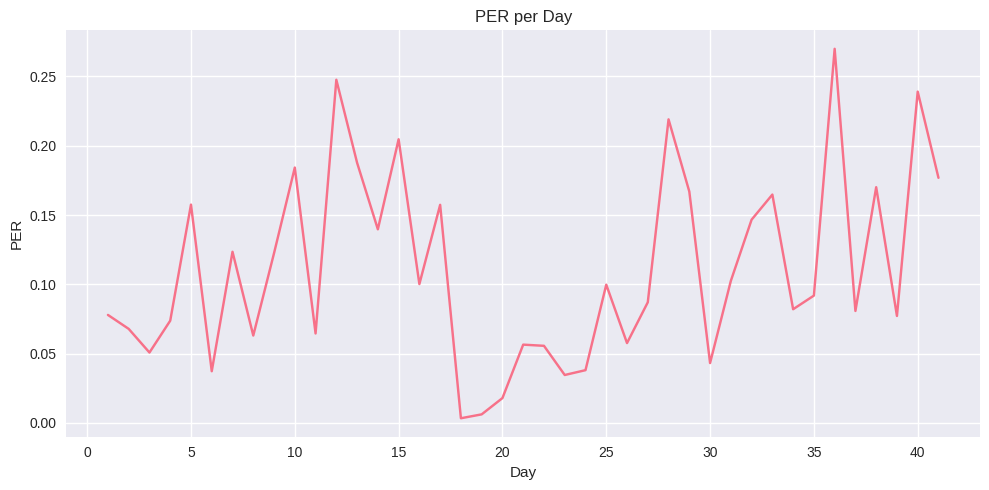

In [15]:
plt.figure(figsize=(10,5))
plt.plot(range(1, len(per_list)+1), per_list)
plt.xlabel("Day")
plt.ylabel("PER")
plt.title("PER per Day")
plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/PER_days.png')
plt.show()

# Creating Confusion Matrix from sampled validation batches

In [17]:
import numpy as np

LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B', 'CH', 'D', 'DH', 'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH', ' | ',
]

# create map excluding BLANK
phoneme_map = {i: ph for i, ph in enumerate(LOGIT_TO_PHONEME) if ph != 'BLANK'}
idx_map = {i: new_i for new_i, i in enumerate(phoneme_map.keys())}  # map old idx -> new idx
n_classes = len(phoneme_map)

conf_matrix = np.zeros((n_classes, n_classes), dtype=int)

for batch_idx in range(len(metrics['decoded_seqs'])):
    decoded_batch = metrics['decoded_seqs'][batch_idx]
    true_batch = metrics['true_seq'][batch_idx]
    phone_lens = metrics['phone_seq_lens'][batch_idx]

    for pred_seq, true_seq, seq_len in zip(decoded_batch, true_batch, phone_lens):
        true_seq_trim = true_seq[:seq_len]  # remove padding
        pred_seq_trim = [p for p in pred_seq if p != 0]  # remove blanks

        min_len = min(len(true_seq_trim), len(pred_seq_trim))
        for t, p in zip(true_seq_trim[:min_len], pred_seq_trim[:min_len]):
            if t in idx_map and p in idx_map:  # skip BLANKs
                conf_matrix[idx_map[t], idx_map[p]] += 1

# compute percent accuracy per class
true_counts = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_perc = conf_matrix / np.maximum(true_counts, 1) * 100

# Plotting Confusion Matrix

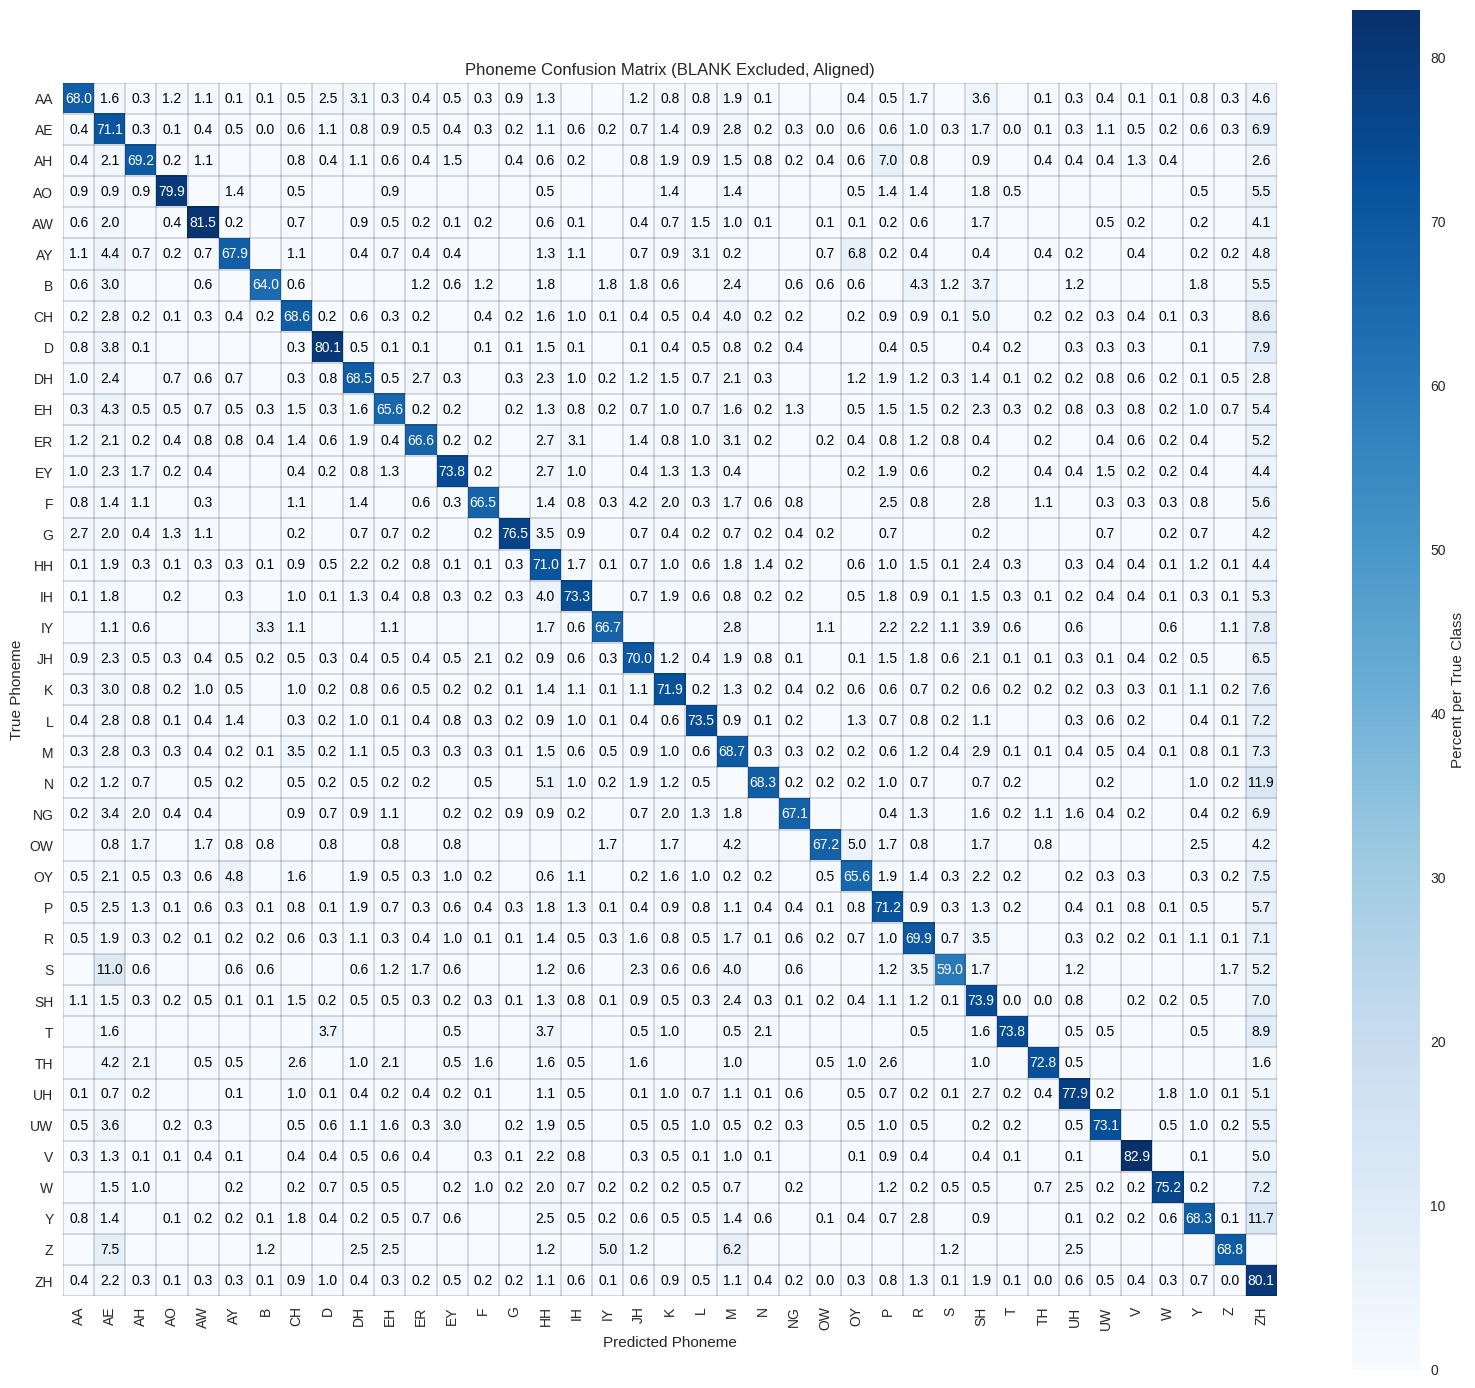

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Slice confusion matrix
conf_matrix_no_blank = conf_matrix[1:, 1:]
n_classes_no_blank = conf_matrix_no_blank.shape[0]

# Labels must match n_classes_no_blank exactly
phoneme_labels = LOGIT_TO_PHONEME[1:1+n_classes_no_blank]  # slice to length 39

# Normalize per true class
true_counts_no_blank = conf_matrix_no_blank.sum(axis=1, keepdims=True)
conf_matrix_perc_no_blank = conf_matrix_no_blank / np.maximum(true_counts_no_blank, 1) * 100

# Plot
fig, ax = plt.subplots(figsize=(16,14))
im = plt.imshow(conf_matrix_perc_no_blank, cmap=plt.cm.Blues, vmin=0, vmax=conf_matrix_perc_no_blank.max())

# Add annotations
for i in range(n_classes_no_blank):
    for j in range(n_classes_no_blank):
        if conf_matrix_perc_no_blank[i,j] > 0:
            plt.text(j, i, f"{conf_matrix_perc_no_blank[i,j]:.1f}",
                     ha="center", va="center",
                     color="white" if conf_matrix_perc_no_blank[i,j]>50 else "black")

# Tick labels
ax.set_xticks(np.arange(n_classes_no_blank))
ax.set_xticklabels(phoneme_labels, rotation=90)
ax.set_yticks(np.arange(n_classes_no_blank))
ax.set_yticklabels(phoneme_labels)

# Turn off gridlines / spines to remove “cross”
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add thin black borders between cells
ax.set_xticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.2)

plt.colorbar(im, label='Percent per True Class')
plt.xlabel("Predicted Phoneme")
plt.ylabel("True Phoneme")
plt.title("Phoneme Confusion Matrix (BLANK Excluded, Aligned)")
plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/confusion_matrix.png')
plt.show()

# Confusion Matrix Classification Report

In [20]:
from sklearn.metrics import classification_report

true_labels_flat = []
pred_labels_flat = []

for batch_idx in range(len(metrics['decoded_seqs'])):
    decoded_batch = metrics['decoded_seqs'][batch_idx]
    true_batch = metrics['true_seq'][batch_idx]
    phone_lens = metrics['phone_seq_lens'][batch_idx]

    for pred_seq, true_seq, seq_len in zip(decoded_batch, true_batch, phone_lens):
        true_seq_trim = true_seq[:seq_len]  # remove padding
        pred_seq_trim = [p for p in pred_seq if p != 0]  # remove blanks

        min_len = min(len(true_seq_trim), len(pred_seq_trim))
        for t, p in zip(true_seq_trim[:min_len], pred_seq_trim[:min_len]):
            if t != 0 and p != 0:  # skip BLANK
                true_labels_flat.append(t)
                pred_labels_flat.append(p)

# Map indices to phoneme strings (optional)
phoneme_labels = LOGIT_TO_PHONEME[1:-1]  # exclude BLANK and ' | '

# Generate classification report
report = classification_report(
    true_labels_flat,
    pred_labels_flat,
    labels=list(range(1, len(phoneme_labels)+1)),  # skip BLANK
    target_names=phoneme_labels,
    digits=3
)

print(report)

              precision    recall  f1-score   support

          AA      0.729     0.697     0.713       657
          AE      0.725     0.669     0.696       767
          AH      0.686     0.708     0.696      2665
          AO      0.698     0.678     0.688       540
          AW      0.678     0.795     0.732       220
          AY      0.791     0.811     0.801       805
           B      0.666     0.676     0.671       460
          CH      0.714     0.640     0.675       164
           D      0.692     0.684     0.688      1255
          DH      0.797     0.800     0.798      1057
          EH      0.634     0.685     0.658       859
          ER      0.672     0.651     0.662       611
          EY      0.675     0.665     0.670       516
           F      0.676     0.737     0.705       479
           G      0.676     0.659     0.668       361
          HH      0.832     0.764     0.796       453
          IH      0.718     0.709     0.714      2046
          IY      0.742    

In [21]:
report = classification_report(
    true_labels_flat,
    pred_labels_flat,
    labels=list(range(1, len(phoneme_labels)+1)),  # skip BLANK
    target_names=phoneme_labels,
    digits=4,
    output_dict=True
)

precision_list = [report[name]["precision"] for name in phoneme_labels]
recall_list    = [report[name]["recall"]    for name in phoneme_labels]
f1_score_list  = [report[name]["f1-score"]  for name in phoneme_labels]
support_list   = [report[name]["support"]   for name in phoneme_labels]

metrics_bars.png


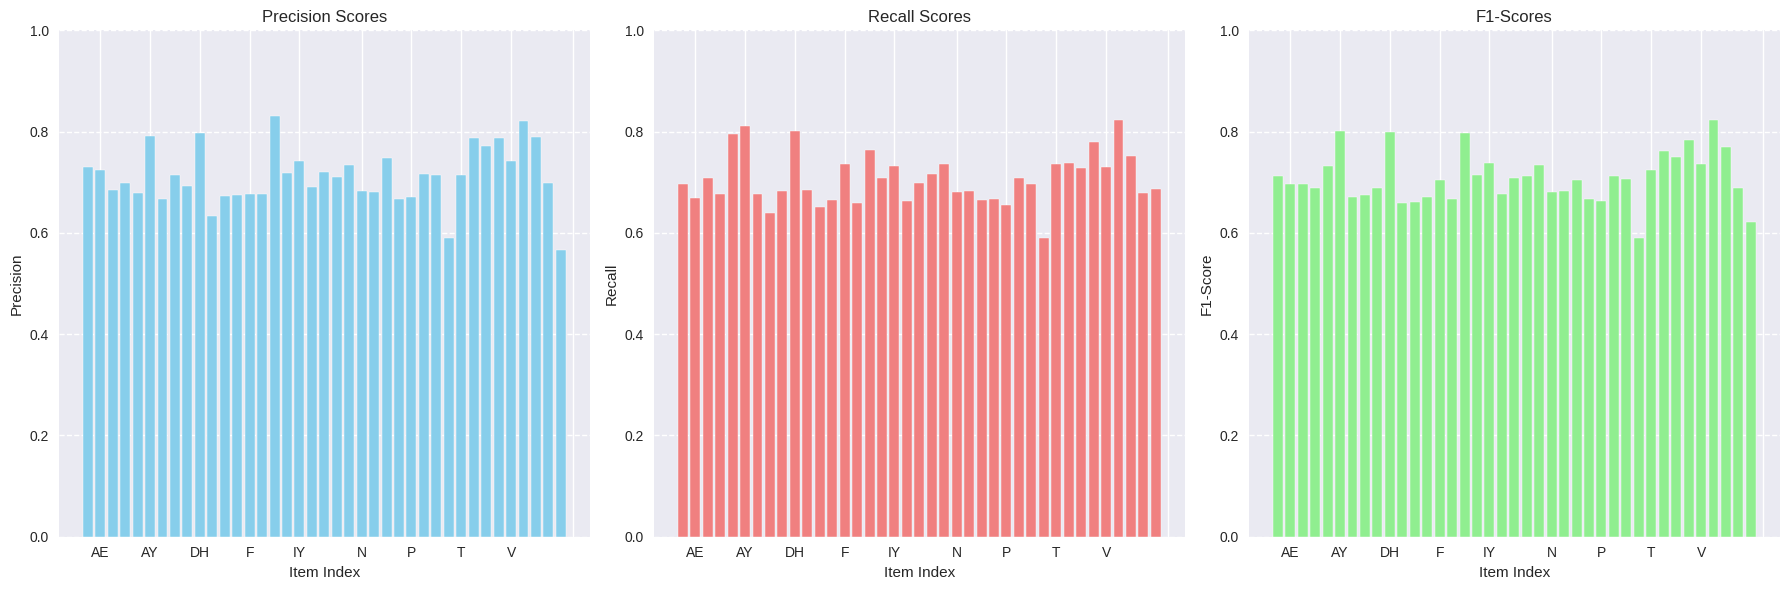

In [22]:
num_items = len(precision_list)

# Create a figure with 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Precision subplot
axes[0].bar(phoneme_labels, precision_list, color='skyblue')
axes[0].set_title('Precision Scores')
axes[0].set_xlabel('Item Index')
axes[0].set_ylabel('Precision')
axes[0].grid(axis='y', linestyle='--')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(np.linspace(1, num_items, 10, dtype=int))

# Recall subplot
axes[1].bar(phoneme_labels, recall_list, color='lightcoral')
axes[1].set_title('Recall Scores')
axes[1].set_xlabel('Item Index')
axes[1].set_ylabel('Recall')
axes[1].grid(axis='y', linestyle='--')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(np.linspace(1, num_items, 10, dtype=int))

# F1-Score subplot
axes[2].bar(phoneme_labels, f1_score_list, color='lightgreen')
axes[2].set_title('F1-Scores')
axes[2].set_xlabel('Item Index')
axes[2].set_ylabel('F1-Score')
axes[2].grid(axis='y', linestyle='--')
axes[2].set_ylim(0, 1)
axes[2].set_xticks(np.linspace(1, num_items, 10, dtype=int))

plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/metrics_bars.png')
print('metrics_bars.png')
plt.show()

In [23]:
def get_lowest_k(arr, k):
    """Return (sorted_values, sorted_indices) for the lowest-k entries."""
    k = min(k, len(arr))
    idx = np.argsort(arr)[:k]          # k smallest indices
    vals = arr[idx]                    # corresponding values
    order = np.argsort(vals)           # sort the k items by value
    return vals[order], (idx + 1)[order]   # +1 for 1-indexed class numbers

def get_highest_k(arr, k):
    """Return (sorted_values, sorted_indices) for the highest-k entries."""
    k = min(k, len(arr))
    idx = np.argsort(arr)[-k:]         # k biggest indices
    vals = arr[idx]                    # corresponding values
    order = np.argsort(vals)         # sort the k items by value
    return vals[order], (idx + 1)[order]   # +1 for 1-indexed class numbers

lowest_k_metric_bars.png


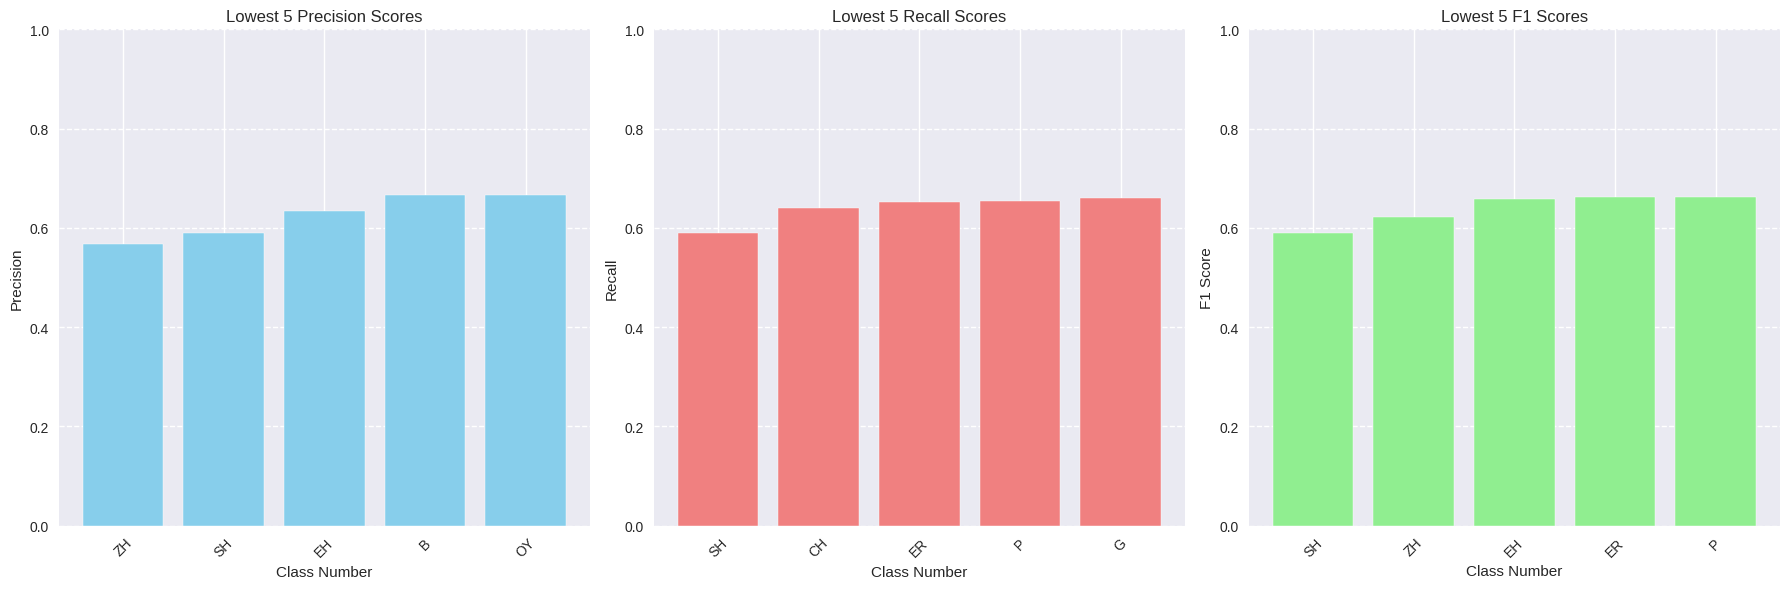

In [24]:
# Convert to numpy arrays
precision_arr = np.array(precision_list)
recall_arr = np.array(recall_list)
f1_arr = np.array(f1_score_list)

# Get sorted lowest-k values + class numbers
prec_vals, prec_classes = get_lowest_k(precision_arr, k)
rec_vals, rec_classes = get_lowest_k(recall_arr, k)
f1_vals, f1_classes = get_lowest_k(f1_arr, k)

# Convert class numbers → phoneme labels
prec_classes = [phoneme_labels[c-1] for c in prec_classes]
rec_classes  = [phoneme_labels[c-1] for c in rec_classes]
f1_classes   = [phoneme_labels[c-1] for c in f1_classes]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision subplot
axes[0].bar(range(k), prec_vals, color='skyblue')
axes[0].set_xticks(range(k))
axes[0].set_xticklabels(prec_classes, rotation=45)
axes[0].set_title(f'Lowest {k} Precision Scores')
axes[0].set_xlabel('Class Number')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--')

# Recall subplot
axes[1].bar(range(k), rec_vals, color='lightcoral')
axes[1].set_xticks(range(k))
axes[1].set_xticklabels(rec_classes, rotation=45)
axes[1].set_title(f'Lowest {k} Recall Scores')
axes[1].set_xlabel('Class Number')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--')

# F1 subplot
axes[2].bar(range(k), f1_vals, color='lightgreen')
axes[2].set_xticks(range(k))
axes[2].set_xticklabels(f1_classes, rotation=45)
axes[2].set_title(f'Lowest {k} F1 Scores')
axes[2].set_xlabel('Class Number')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f"./metrics/{MODEL_NAME}/lowest_k_metric_bars.png")
print("lowest_k_metric_bars.png")
plt.show()

highest_k_metric_bars.png


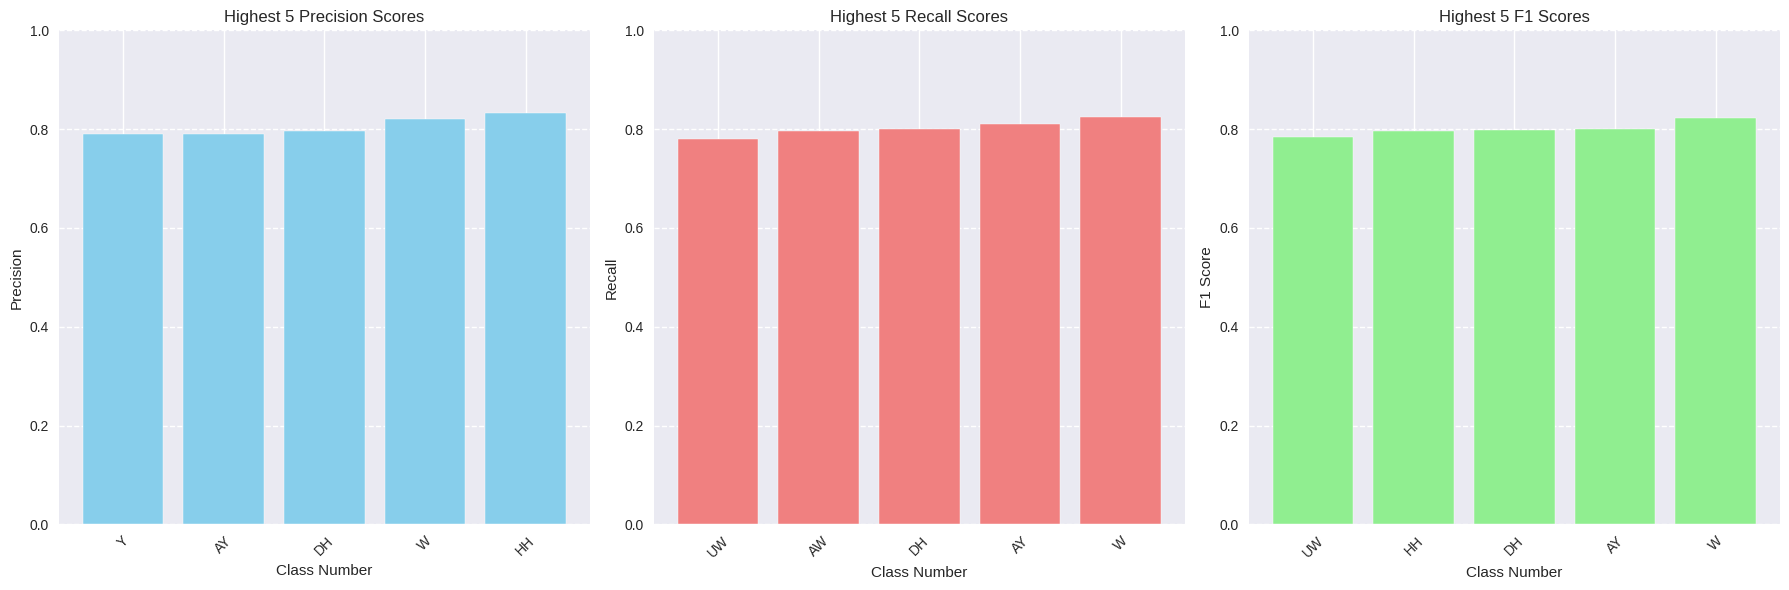

In [25]:
# Get sorted lowest-k values + class numbers
prec_vals, prec_classes = get_highest_k(precision_arr, k)
rec_vals, rec_classes = get_highest_k(recall_arr, k)
f1_vals, f1_classes = get_highest_k(f1_arr, k)

# Convert class numbers → phoneme labels
prec_classes = [phoneme_labels[c-1] for c in prec_classes]
rec_classes  = [phoneme_labels[c-1] for c in rec_classes]
f1_classes   = [phoneme_labels[c-1] for c in f1_classes]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision subplot
axes[0].bar(range(k), prec_vals, color='skyblue')
axes[0].set_xticks(range(k))
axes[0].set_xticklabels(prec_classes, rotation=45)
axes[0].set_title(f'Highest {k} Precision Scores')
axes[0].set_xlabel('Class Number')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--')

# Recall subplot
axes[1].bar(range(k), rec_vals, color='lightcoral')
axes[1].set_xticks(range(k))
axes[1].set_xticklabels(rec_classes, rotation=45)
axes[1].set_title(f'Highest {k} Recall Scores')
axes[1].set_xlabel('Class Number')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--')

# F1 subplot
axes[2].bar(range(k), f1_vals, color='lightgreen')
axes[2].set_xticks(range(k))
axes[2].set_xticklabels(f1_classes, rotation=45)
axes[2].set_title(f'Highest {k} F1 Scores')
axes[2].set_xlabel('Class Number')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f"./metrics/{MODEL_NAME}/highest_k_metric_bars.png")
print("highest_k_metric_bars.png")
plt.show()

In [26]:
avg_precision = np.sum(precision_list) / 50
avg_recall = np.sum(recall_list) / 50
avg_f1_score = np.sum(f1_score_list) / 50

print("Average Precision =", avg_precision)
print("Average Recall =", avg_recall)
print("Average F1-Score =", avg_f1_score)

Average Precision = 0.5561821146797721
Average Recall = 0.5513897694939405
Average F1-Score = 0.5533066299939345


# Decoding Phonemes

In [28]:
def decode_phonemes(decoded_seqs, mapping=LOGIT_TO_PHONEME):
    all_sequences = []
    for batch in decoded_seqs:
        batch_seqs = []
        for seq in batch:
            # Map indices to phonemes
            phonemes = [mapping[i] for i in seq]

            # Remove 'BLANK's
            phonemes = [p for p in phonemes if p != 'BLANK']

            # Collapse consecutive ' | '
            collapsed = []
            for p in phonemes:
                if p != ' | ':
                    collapsed.append(p)
                else:
                    if len(collapsed) == 0 or collapsed[-1] != '|':
                        collapsed.append('|')

            # Join as string and strip leading/trailing '|'
            s = ' '.join(collapsed).strip()
            if s.startswith('|'):
                s = s[1:].strip()
            if s.endswith('|'):
                s = s[:-1].strip()

            batch_seqs.append(s)
        all_sequences.append(batch_seqs)
    return all_sequences

# Example usage
readable_seqs = decode_phonemes(metrics['decoded_seqs'])
print(readable_seqs[0][:1])

['Y UW | K AE N | S IY | DH AH | K OW L D | AE T | IH T S | P OY N T | AE Z | W EH L']
